# Library 

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# Get the dataset

In [79]:
df = pd.read_csv("IMDB_preprocessed.csv")

df.head()

,review,sentiment,label
0,one reviewers mention watch oz episode youll h...,positive,1
1,wonderful little production film technique una...,positive,1
2,think wonderful way spend time hot summer week...,positive,1
3,basically theres family little boy jake think ...,negative,0
4,petter matteis love time money visually stun f...,positive,1


# Train and test data

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (40000,)
Test size: (10000,)


# Logistic Regression

## One Hot Encoding

In [81]:
text_pipeline_log_one = Pipeline(
    steps=[
        ("encoding", CountVectorizer(binary=True,stop_words='english', ngram_range=(1, 2), max_features=5000)),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

text_pipeline_log_one.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoding', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [82]:
y_pred_log_one = text_pipeline_log_one.predict(X_test)
y_proba_log_one = text_pipeline_log_one.predict_proba(X_test)

In [83]:
results_log_one = pd.DataFrame({
    "true_result": y_test.values,
    "predicted_class": y_pred_log_one,
    "predicted_probability_positive": y_proba_log_one[:,1]
})

results_log_one.head(10)

,true_result,predicted_class,predicted_probability_positive
0,0,0,0.108058
1,0,0,0.271208
2,1,1,0.999847
3,0,0,0.108522
4,0,0,0.084249
5,0,0,0.001436
6,0,0,0.027079
7,0,0,0.492023
8,0,0,0.416543
9,0,0,0.000030


#### Accuracy, Precision, Recall, F1-score of OneHotEncoding

In [84]:
accuracy_log_one = accuracy_score(y_test, y_pred_log_one)
precision_log_one = precision_score(y_test, y_pred_log_one)
recall_log_one = recall_score(y_test, y_pred_log_one)
f1_log_one = f1_score(y_test, y_pred_log_one)

print(f"Accuracy:  {accuracy_log_one}")
print(f"Precision: {precision_log_one}")
print(f"Recall:    {recall_log_one}")
print(f"F1-score:  {f1_log_one}")

Accuracy:  0.872
Precision: 0.8639921722113503
Recall:    0.883
F1-score:  0.8733926805143423


In [85]:
print(classification_report(
    y_test,
    y_pred_log_one,
    target_names=["Negative","Positive"]
))

              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      5000
    Positive       0.86      0.88      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



#### Error analysis 

In [86]:
results = pd.DataFrame({
    "message": X_test,
    "true": y_test,
    "predicted": y_pred_log_one
})

mistakes = results[results["true"] != results["predicted"]]

mistakes.head(10)

,message,true,predicted
41611,admit create great expectations watch friends ...,1,0
47698,watch movie dvd think act good story leave lot...,1,0
31882,film list make film available something weird ...,0,1
1591,great movie tho cast especially kid admirably ...,1,0
48388,order enjoy fur imaginary portrait diane arbus...,0,1
20169,quite fan novelistscreenwriter michael chabon ...,0,1
36678,would probably want give movie zero climax inv...,0,1
28105,watch movie watch practical magic older film f...,1,0
45621,ladies gentlemen weve really get winner actual...,1,0
28165,appear extra location journalist cover dain cu...,0,1


#### Train and test score

In [87]:
y_train_log_one = text_pipeline_log_one.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_log_one)
test_accuracy = accuracy_score(y_test, y_pred_log_one)
print(f"Training accuracy: {train_accuracy}")
print(f"Testing accuracy: {test_accuracy}")

train_precision = precision_score(y_train, y_train_log_one)
test_precision = precision_score(y_test, y_pred_log_one)
print(f"Training precision: {train_precision}")
print(f"Testing precision: {test_precision}")

train_recall = recall_score(y_train,y_train_log_one)
test_recall = recall_score(y_test, y_pred_log_one)
print(f"Training recall: {train_recall}")
print(f"Testing recall: {test_recall}")

train_f1_score = f1_score(y_train,y_train_log_one)
test_f1_score = f1_score(y_test,y_pred_log_one)
print(f"Training F1-score: {train_f1_score}")
print(f"Testing F1-score: {test_f1_score}")

Training accuracy: 0.929275
Testing accuracy: 0.872
Training precision: 0.9258891810109628
Testing precision: 0.8639921722113503
Training recall: 0.93325
Testing recall: 0.883
Training F1-score: 0.9295550188002689
Testing F1-score: 0.8733926805143423


#### Confusion matrix of OneHotEncoding

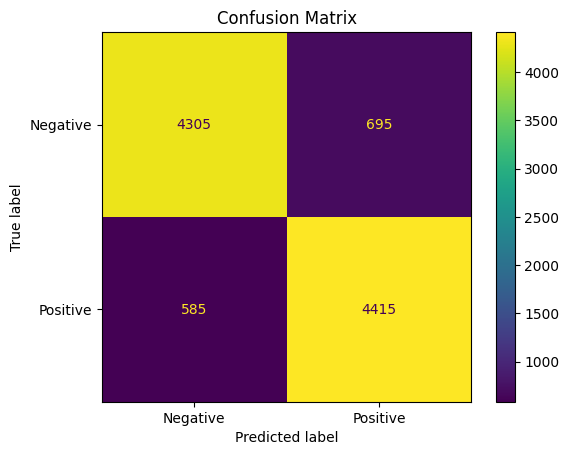

In [88]:
cm_log_one = confusion_matrix(y_test, y_pred_log_one)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log_one,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Bag of Words

In [89]:

text_pipeline_log_bag = Pipeline(
    steps=[
        ("bagging", CountVectorizer(stop_words='english', ngram_range=(1, 2), max_features=5000)),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

text_pipeline_log_bag.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('bagging', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [90]:
y_pred_log_bag = text_pipeline_log_bag.predict(X_test)
y_proba_log_bag = text_pipeline_log_bag.predict_proba(X_test)

In [91]:
results_log_bag = pd.DataFrame({
    "true_result": y_test.values,
    "predicted_class": y_pred_log_bag,
    "predicted_probability_positive": y_proba_log_bag[:,1]
})

results_log_bag.head(10)

,true_result,predicted_class,predicted_probability_positive
0,0,0,0.275930
1,0,0,0.491633
2,1,1,0.999663
3,0,0,0.076192
4,0,0,0.074821
5,0,0,0.001187
6,0,0,0.007821
7,0,1,0.718713
8,0,0,0.475943
9,0,0,0.000031


#### Accuracy, Precision, Recall, F1-score of Bag of Words

In [92]:
accuracy_log_bag = accuracy_score(y_test, y_pred_log_bag)
precision_log_bag = precision_score(y_test, y_pred_log_bag)
recall_log_bag = recall_score(y_test, y_pred_log_bag)
f1_log_bag = f1_score(y_test, y_pred_log_bag)

print(f"Accuracy:  {accuracy_log_bag}")
print(f"Precision: {precision_log_bag}")
print(f"Recall:    {recall_log_bag}")
print(f"F1-score:  {f1_log_bag}")

Accuracy:  0.8698
Precision: 0.8651263823064771
Recall:    0.8762
F1-score:  0.8706279809220986


In [93]:
print(classification_report(
    y_test,
    y_pred_log_bag,
    target_names=["Negative","Positive"]
))

              precision    recall  f1-score   support

    Negative       0.87      0.86      0.87      5000
    Positive       0.87      0.88      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



#### Error analysis

In [94]:
results = pd.DataFrame({
    "message": X_test,
    "true": y_test,
    "predicted": y_pred_log_bag
})

mistakes = results[results["true"] != results["predicted"]]

mistakes.head(10)

,message,true,predicted
40882,movie really wack really nothing nice say besi...,0,1
41611,admit create great expectations watch friends ...,1,0
31882,film list make film available something weird ...,0,1
1591,great movie tho cast especially kid admirably ...,1,0
7266,farrah fawcett give award nominate performance...,1,0
20169,quite fan novelistscreenwriter michael chabon ...,0,1
47706,recommendation gloria grahame run kind orphana...,0,1
36678,would probably want give movie zero climax inv...,0,1
46536,cant believe comment show show genius sure doe...,1,0
39806,ive see branaghs hamlet branagh old speak freq...,1,0


#### Train and test score

In [95]:
y_train_log_bag = text_pipeline_log_one.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_log_bag)
test_accuracy = accuracy_score(y_test, y_pred_log_bag)
print(f"Training accuracy: {train_accuracy}")
print(f"Testing accuracy: {test_accuracy}")

train_precision = precision_score(y_train, y_train_log_bag)
test_precision = precision_score(y_test, y_pred_log_bag)
print(f"Training precision: {train_precision}")
print(f"Testing precision: {test_precision}")

train_recall = recall_score(y_train,y_train_log_bag)
test_recall = recall_score(y_test, y_pred_log_bag)
print(f"Training recall: {train_recall}")
print(f"Testing recall: {test_recall}")

train_f1_score = f1_score(y_train,y_train_log_bag)
test_f1_score = f1_score(y_test,y_pred_log_bag)
print(f"Training F1-score: {train_f1_score}")
print(f"Testing F1-score: {test_f1_score}")

Training accuracy: 0.929275
Testing accuracy: 0.8698
Training precision: 0.9258891810109628
Testing precision: 0.8651263823064771
Training recall: 0.93325
Testing recall: 0.8762
Training F1-score: 0.9295550188002689
Testing F1-score: 0.8706279809220986


#### Confusion matrix of Bag of Words

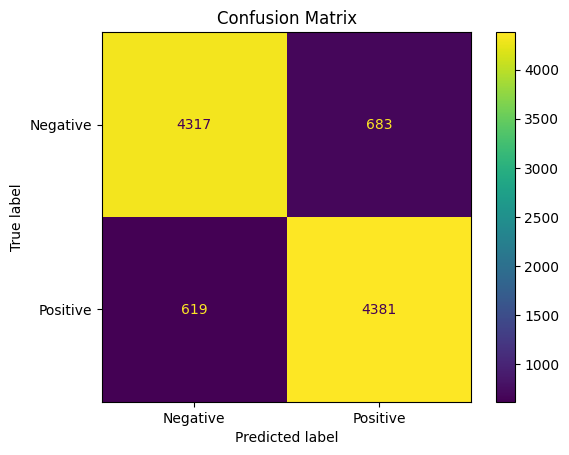

In [96]:
cm_log_bag = confusion_matrix(y_test, y_pred_log_bag)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log_bag,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## TF-IDF

In [97]:
text_pipeline_log_tfidf = Pipeline(
    steps=[
        ("vectorizing", TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=5000)),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

text_pipeline_log_tfidf.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [98]:
y_pred_log_tfidf = text_pipeline_log_tfidf.predict(X_test)
y_proba_log_tfidf = text_pipeline_log_tfidf.predict_proba(X_test)

In [99]:
results_log_tfidf = pd.DataFrame({
    "true results": y_test.values,
    "predicted_class": y_pred_log_tfidf,
    "predicted_probability_positive": y_proba_log_tfidf[:,1]
})

results_log_tfidf.head(10)

,true results,predicted_class,predicted_probability_positive
0,0,0,0.224518
1,0,1,0.639960
2,1,1,0.928322
3,0,0,0.272746
4,0,0,0.120956
5,0,0,0.027380
6,0,0,0.122113
7,0,1,0.740345
8,0,0,0.276760
9,0,0,0.024615


#### Accuracy, Precision, Recall, F1-score of TF - IDF

In [100]:
accuracy_log_tfidf = accuracy_score(y_test, y_pred_log_tfidf)
precision_log_tfidf = precision_score(y_test, y_pred_log_tfidf)
recall_log_tfidf = recall_score(y_test, y_pred_log_tfidf)
f1_log_tfidf = f1_score(y_test, y_pred_log_tfidf)

print(f"Accuracy:  {accuracy_log_tfidf}")
print(f"Precision: {precision_log_tfidf}")
print(f"Recall:    {recall_log_tfidf}")
print(f"F1-score:  {f1_log_tfidf}")

Accuracy:  0.8853
Precision: 0.8757558026136142
Recall:    0.898
F1-score:  0.8867384220400909


In [101]:
print(classification_report(
    y_test,
    y_pred_log_tfidf,
    target_names=["Negative","Positive"]
))

              precision    recall  f1-score   support

    Negative       0.90      0.87      0.88      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



#### Error analysis

In [102]:
results = pd.DataFrame({
    "message": X_test,
    "true": y_test,
    "predicted": y_pred_log_tfidf
})

mistakes = results[results["true"] != results["predicted"]]

mistakes.head(10)

,message,true,predicted
39791,story bride fair amuse engage one filmmakers c...,0,1
40882,movie really wack really nothing nice say besi...,0,1
41611,admit create great expectations watch friends ...,1,0
40714,little quentin seem master art cake eat itas u...,0,1
31882,film list make film available something weird ...,0,1
1591,great movie tho cast especially kid admirably ...,1,0
7266,farrah fawcett give award nominate performance...,1,0
11840,know brad linaweaver florida state u early ins...,0,1
49387,murder mesopotamia always consider one better ...,1,0
48388,order enjoy fur imaginary portrait diane arbus...,0,1


#### Train and test score

In [103]:
y_train_log_tfidf = text_pipeline_log_one.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_log_tfidf)
test_accuracy = accuracy_score(y_test, y_pred_log_tfidf)
print(f"Training accuracy: {train_accuracy}")
print(f"Testing accuracy: {test_accuracy}")

train_precision = precision_score(y_train, y_train_log_tfidf)
test_precision = precision_score(y_test, y_pred_log_tfidf)
print(f"Training precision: {train_precision}")
print(f"Testing precision: {test_precision}")

train_recall = recall_score(y_train,y_train_log_tfidf)
test_recall = recall_score(y_test, y_pred_log_tfidf)
print(f"Training recall: {train_recall}")
print(f"Testing recall: {test_recall}")

train_f1_score = f1_score(y_train,y_train_log_tfidf)
test_f1_score = f1_score(y_test,y_pred_log_tfidf)
print(f"Training F1-score: {train_f1_score}")
print(f"Testing F1-score: {test_f1_score}")

Training accuracy: 0.929275
Testing accuracy: 0.8853
Training precision: 0.9258891810109628
Testing precision: 0.8757558026136142
Training recall: 0.93325
Testing recall: 0.898
Training F1-score: 0.9295550188002689
Testing F1-score: 0.8867384220400909


#### Confusion matrix of TF-IDF

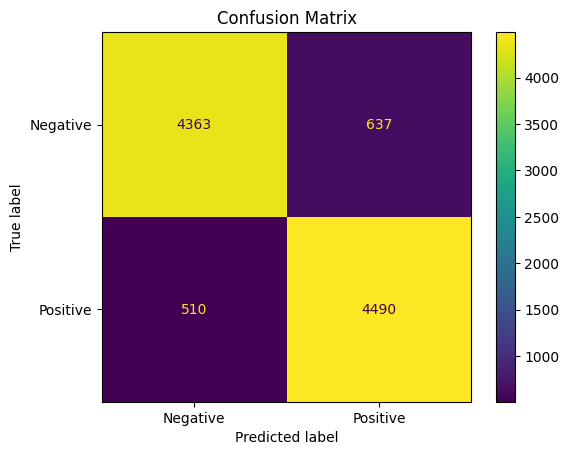

In [104]:
cm_log_tfidf = confusion_matrix(y_test, y_pred_log_tfidf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log_tfidf,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()